<p align="center">
  <a href="https://github.com/wavekat/wavekat-lab">
    <img src="https://github.com/wavekat/wavekat-brand/raw/main/assets/banners/wavekat-lab-narrow.svg" alt="WaveKat Lab">
  </a>
</p>

# 04 — Score candidates with the current zh smart-turn model

Run the current zh smart-turn checkpoint over every candidate clip
from `candidates.parquet` (notebook 03) and write
`candidates_scored.parquet` with two extra columns:

- `model_prob` — sigmoid output, `[0, 1]`.
- `model_pred` — `1` if `model_prob > threshold`, else `0`. The
  threshold comes from the checkpoint's `threshold.json` (the F1-best
  cut chosen on the held-out val split during training).

This becomes the second consensus signal in notebook 06 — alongside
the structural label (RAMC + VAD) and the LLM verdict (notebook 05).

Implementation notes:

- Audio is read **once per session**: we group candidates by
  `session_id`, load the full WAV with soundfile, then slice each
  clip out of the in-memory array. Re-decoding the same multi-hundred-
  MB WAV per row would dominate runtime.
- Each clip is **truncated to the trailing 8 s** (`chunk_length` in
  `preprocessor_config.json`) using the same
  `truncate_to_last_n_seconds` helper the training pipeline used —
  smart-turn looks at the *end* of an utterance, so left-padding /
  truncating from the front matches the train-time distribution.
- Inference is batched (`BATCH_SIZE = 32` on MPS / CUDA, 8 on CPU) so
  the per-call overhead of the Whisper encoder is amortized.

## Configure paths

In [21]:
from pathlib import Path

MINING_ROOT       = Path("../../datasets/smart-turn-zh-mining").resolve()
CANDIDATES_IN     = MINING_ROOT / "candidates.parquet"
CANDIDATES_OUT    = MINING_ROOT / "candidates_scored.parquet"
WAV_DIR           = Path("../../datasets/MagicData-RAMC/MDT2021S003/WAV").resolve()

CHECKPOINT_DIR    = Path("../../checkpoints/smart-turn-zh-0502/specaugment").resolve()

SAMPLE_RATE   = 16_000
CHUNK_LENGTH  = 8           # seconds; matches preprocessor_config.json

print(f"candidates : {CANDIDATES_IN.name}")
print(f"out        : {CANDIDATES_OUT.name}")
print(f"wavs       : {WAV_DIR.name}")
print(f"checkpoint : {CHECKPOINT_DIR.name}")
print("✅ paths configured")

candidates : candidates.parquet
out        : candidates_scored.parquet
wavs       : WAV
checkpoint : specaugment
✅ paths configured


## Load model + feature extractor

We import `SmartTurnModel` from `notebooks/smart-turn/smart_turn.py`
(the same class the training notebooks use), then load the trained
weights from `checkpoints/smart-turn-zh/`. The Whisper feature
extractor reads its config from the same directory — keeping
preprocessor and weights co-located prevents drift.

In [22]:
import json
import sys

import numpy as np
import torch
from transformers import WhisperFeatureExtractor

# Make ../smart-turn importable so we reuse SmartTurnModel +
# truncate_to_last_n_seconds rather than redefining them here.
SMART_TURN_PKG = (Path("../smart-turn")).resolve()
if str(SMART_TURN_PKG) not in sys.path:
    sys.path.insert(0, str(SMART_TURN_PKG))

from smart_turn import SmartTurnModel, pick_device, truncate_to_last_n_seconds  # noqa: E402

device = pick_device()

model = SmartTurnModel.from_pretrained(CHECKPOINT_DIR).to(device).eval()
fe = WhisperFeatureExtractor.from_pretrained(CHECKPOINT_DIR)

thr_path = CHECKPOINT_DIR / "threshold.json"
if thr_path.exists():
    THRESHOLD = float(json.loads(thr_path.read_text())["threshold"])
else:
    THRESHOLD = 0.5

print(f"device     : {device}")
print(f"params     : {sum(p.numel() for p in model.parameters()):,}")
print(f"threshold  : {THRESHOLD:.3f}")
print("✅ model + feature extractor loaded")

Task was destroyed but it is pending!
task: <Task pending name='Task-566' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/eason/Developer/_wavekat/wavekat-lab/.venv/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-567' coro=<Kernel.shell_main() running at /Users/eason/Developer/_wavekat/wavekat-lab/.venv/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/eason/Developer/_wavekat/wavekat-lab/.venv/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py:563]>
/opt/homebrew/Cellar/python@3.12/3.12.12/Frameworks/Python.framework/Versions/3.12/lib/python3.12/collections/__init__.py:449: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  result = tuple_new(cls, iterable)
Task was destroyed but it is pending!
task: <Task pending name='Task-567' coro=<Kernel.shell_main() running at /Users/eason/Developer/_wavekat/wavekat-lab/.

Loading weights:   0%|          | 0/80 [00:00<?, ?it/s]

device     : mps
params     : 8,000,386
threshold  : 0.210
✅ model + feature extractor loaded


## Load candidates

Re-uses notebook 03's output. We sort by `session_id` so the
scoring loop reads each WAV exactly once.

In [23]:
import pandas as pd

cand = pd.read_parquet(CANDIDATES_IN)
cand = cand.sort_values(["session_id", "candidate_idx"]).reset_index(drop=True)

print(f"candidates : {len(cand):,}")
print(f"sessions   : {cand['session_id'].nunique()}")
print(f"label dist :")
print(cand["label"].value_counts().to_string())
print("✅ candidates loaded")

candidates : 33,943
sessions   : 349
label dist :
label
0    19959
1    13984
✅ candidates loaded


## Audio + feature helpers

`read_wav_16k_mono` mirrors notebook 02 — soundfile, no
torchaudio/torchcodec dependency. `clip_to_features` slices the
trailing 8 s ending at `clip_end_s`, then extracts log-mel features.

We end the slice at `clip_end_s` (not `clip_start_s + duration`)
because `truncate_to_last_n_seconds` left-pads if the clip is
shorter than 8 s, which is exactly what we want: the model decides
from the **last** moments of the clip.

In [24]:
import soundfile as sf

_audio_cache: dict[str, np.ndarray] = {}

def read_wav_16k_mono(wav_path: Path) -> np.ndarray:
    """Read a 16 kHz mono RAMC WAV as float32 in [-1, 1]."""
    arr, sr = sf.read(str(wav_path), dtype="float32", always_2d=False)
    if arr.ndim > 1:
        arr = arr.mean(axis=1)
    if sr != SAMPLE_RATE:
        import librosa
        arr = librosa.resample(arr, orig_sr=sr, target_sr=SAMPLE_RATE)
    return arr.astype(np.float32, copy=False)

def slice_clip(audio: np.ndarray, start_s: float, end_s: float) -> np.ndarray:
    """Return audio[start:end] clamped to bounds."""
    start = max(0, int(round(start_s * SAMPLE_RATE)))
    end   = min(len(audio), int(round(end_s   * SAMPLE_RATE)))
    if end <= start:
        return np.zeros(SAMPLE_RATE * CHUNK_LENGTH, dtype=np.float32)
    return audio[start:end]

def clip_to_input_features(audio: np.ndarray, start_s: float, end_s: float) -> torch.Tensor:
    clip = slice_clip(audio, start_s, end_s)
    clip = truncate_to_last_n_seconds(clip, SAMPLE_RATE, CHUNK_LENGTH)
    feats = fe(
        clip,
        sampling_rate=SAMPLE_RATE,
        return_tensors="pt",
        padding="max_length",
        max_length=CHUNK_LENGTH * SAMPLE_RATE,
        truncation=True,
        do_normalize=True,
    )
    return feats["input_features"].squeeze(0)

print("✅ helpers ready")

✅ helpers ready


## Smoke test — score one batch

Sanity check the full path on the first 8 candidates before
committing to the full run. Confirms the WAV loads, the feature
extractor returns the expected shape, and the model produces
non-degenerate probabilities.

In [25]:
from IPython.display import Audio, Markdown, display

smoke = cand.head(8).copy()
first_session = smoke["session_id"].iloc[0]
audio = read_wav_16k_mono(WAV_DIR / f"{first_session}.wav")

smoke_rows = [r for r in smoke.itertuples() if r.session_id == first_session]
feats = torch.stack([
    clip_to_input_features(audio, row.clip_start_s, row.clip_end_s)
    for row in smoke_rows
]).to(device)

with torch.inference_mode():
    probs = model(input_features=feats)["logits"].cpu().numpy()

print(f"audio len   : {len(audio) / SAMPLE_RATE:.1f} s")
print(f"feat shape  : {tuple(feats.shape)}")
print(f"prob sample : {np.round(probs, 3).tolist()}")
assert feats.shape[1:] == (80, 800), feats.shape
assert probs.min() >= 0.0 and probs.max() <= 1.0

for row, prob in zip(smoke_rows, probs):
    pred = "END_OF_TURN" if prob > THRESHOLD else "CONTINUATION"
    display(Markdown(
        f"**prob=`{prob:.3f}` → `{pred}`**  "
        f"label=`{row.label}`  source=`{row.source}`  "
        f"clip=`[{row.clip_start_s:.2f}, {row.clip_end_s:.2f}]`  \n"
        f"text: {row.text!r}"
    ))
    clip = slice_clip(audio, float(row.clip_start_s), float(row.clip_end_s))
    display(Audio(clip, rate=SAMPLE_RATE))

print("✅ smoke test passed")

audio len   : 843.4 s
feat shape  : (8, 80, 800)
prob sample : [0.13099999725818634, 0.8600000143051147, 0.10400000214576721, 0.6480000019073486, 0.10100000351667404, 0.10599999874830246, 0.11500000208616257, 0.7900000214576721]


**prob=`0.131` → `CONTINUATION`**  label=`0`  source=`intra_utterance_cut`  clip=`[12.20, 13.63]`  
text: '就是觉得'

**prob=`0.860` → `END_OF_TURN`**  label=`1`  source=`speaker_change`  clip=`[44.62, 47.68]`  
text: '可能会要更蓝一些，因为现在'

**prob=`0.104` → `CONTINUATION`**  label=`0`  source=`intra_utterance_cut`  clip=`[49.42, 50.98]`  
text: '现在车辆也，也'

**prob=`0.648` → `END_OF_TURN`**  label=`0`  source=`intra_utterance_cut`  clip=`[53.45, 58.98]`  
text: '废弃的排放量也，也是工厂那些排，工厂的那些废弃排放'

**prob=`0.101` → `CONTINUATION`**  label=`0`  source=`intra_utterance_cut`  clip=`[63.44, 66.21]`  
text: '其实我觉得现在中国的这'

**prob=`0.106` → `CONTINUATION`**  label=`0`  source=`intra_utterance_cut`  clip=`[71.98, 73.95]`  
text: '我个人认为，个'

**prob=`0.115` → `CONTINUATION`**  label=`0`  source=`intra_utterance_cut`  clip=`[86.98, 88.96]`  
text: '环境会比其他国'

**prob=`0.790` → `END_OF_TURN`**  label=`1`  source=`speaker_change`  clip=`[105.53, 109.50]`  
text: '然后那些废气排放也没有，当时也没有想到过'

✅ smoke test passed


## Score every candidate

Walk through `cand` session by session. For each session we:

1. Read the WAV once.
2. Build feature tensors for every candidate from that session.
3. Forward in `BATCH_SIZE`-sized chunks.
4. Drop the audio array before moving to the next session so memory
   stays flat.

Results land in `model_prob` / `model_pred` columns aligned to
`cand`'s row order.

In [26]:
from tqdm.auto import tqdm

BATCH_SIZE = 8 if device.type == "cpu" else 32

probs_out = np.full(len(cand), np.nan, dtype=np.float32)

session_groups = cand.groupby("session_id", sort=False)
pbar = tqdm(session_groups, total=session_groups.ngroups, desc="Sessions")

for session_id, group in pbar:
    wav_path = WAV_DIR / f"{session_id}.wav"
    if not wav_path.exists():
        pbar.write(f"  skip {session_id}: wav missing")
        continue
    audio = read_wav_16k_mono(wav_path)

    row_indices = group.index.to_numpy()
    feat_list = [
        clip_to_input_features(audio, row.clip_start_s, row.clip_end_s)
        for row in group.itertuples()
    ]

    for i in range(0, len(feat_list), BATCH_SIZE):
        batch = torch.stack(feat_list[i : i + BATCH_SIZE]).to(device)
        with torch.inference_mode():
            batch_probs = model(input_features=batch)["logits"].cpu().numpy()
        probs_out[row_indices[i : i + BATCH_SIZE]] = batch_probs

    del audio

n_scored = int(np.isfinite(probs_out).sum())
print(f"scored     : {n_scored:,} / {len(cand):,}")
print("✅ inference complete")

Sessions:   0%|          | 0/349 [00:00<?, ?it/s]

scored     : 33,943 / 33,943
✅ inference complete


## Save scored candidates

In [27]:
scored = cand.copy()
scored["model_prob"] = probs_out
scored["model_pred"] = (probs_out > THRESHOLD).astype(np.int8)
scored.loc[~np.isfinite(probs_out), "model_pred"] = -1  # sentinel: not scored

tmp_path = CANDIDATES_OUT.with_suffix(".parquet.tmp")
scored.to_parquet(tmp_path, index=False)
tmp_path.replace(CANDIDATES_OUT)

print(f"rows       : {len(scored):,}")
print(f"out        : {CANDIDATES_OUT.name} ({CANDIDATES_OUT.stat().st_size / 1e6:.1f} MB)")
print("✅ candidates_scored.parquet written")

rows       : 33,943
out        : candidates_scored.parquet (3.2 MB)
✅ candidates_scored.parquet written


## Calibration view

Two quick views over the model output:

1. **Agreement with the structural label** — how often does
   `model_pred == label`? Per-source breakdown tells us whether the
   model is more reliable on speaker-change EOTs vs intra-utterance
   continuations.
2. **Probability histogram by label** — the further the two
   distributions are pulled apart, the more useful the model signal
   is in the consensus router (notebook 06).

These are *diagnostic*, not pass/fail — the consensus pipeline is
designed to tolerate disagreement (route to human review) rather
than demand model perfection.

In [28]:
scored_ok = scored[scored["model_pred"] != -1]

print("agreement with structural label:")
for source, sub in scored_ok.groupby("source"):
    agree = (sub["model_pred"] == sub["label"]).mean()
    print(f"  {source:22s} {len(sub):>6,}  agree={agree:.3f}")

print("\nprob distribution by structural label:")
for lbl, sub in scored_ok.groupby("label"):
    p = sub["model_prob"].to_numpy()
    qs = np.quantile(p, [0.10, 0.25, 0.50, 0.75, 0.90])
    print(
        f"  label={lbl} n={len(sub):>6,}  "
        f"p10={qs[0]:.2f}  p25={qs[1]:.2f}  p50={qs[2]:.2f}  "
        f"p75={qs[3]:.2f}  p90={qs[4]:.2f}"
    )
print("✅ calibration summary printed")

agreement with structural label:
  intra_utterance_cut    19,959  agree=0.507
  speaker_change         13,984  agree=0.910

prob distribution by structural label:
  label=0 n=19,959  p10=0.10  p25=0.11  p50=0.20  p75=0.85  p90=0.86
  label=1 n=13,984  p10=0.25  p25=0.84  p50=0.86  p75=0.86  p90=0.86
✅ calibration summary printed


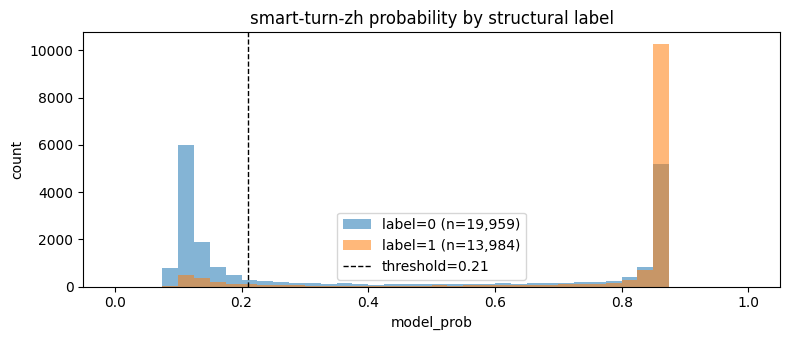

✅ histogram drawn


In [29]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 3.5))
bins = np.linspace(0, 1, 41)
for lbl, color in [(0, "tab:blue"), (1, "tab:orange")]:
    sub = scored_ok[scored_ok["label"] == lbl]["model_prob"]
    ax.hist(sub, bins=bins, alpha=0.55, label=f"label={lbl} (n={len(sub):,})", color=color)
ax.axvline(THRESHOLD, color="k", linestyle="--", linewidth=1, label=f"threshold={THRESHOLD:.2f}")
ax.set_xlabel("model_prob")
ax.set_ylabel("count")
ax.set_title("smart-turn-zh probability by structural label")
ax.legend()
fig.tight_layout()
plt.show()
print("✅ histogram drawn")

## Top-10 most-confident clips per direction

Sort the scored candidates by `model_prob` and embed the audio for the
two extremes — the model's strongest end-of-turn picks (highest
probability) and its strongest continuation picks (lowest probability).
This is the qualitative companion to the histogram above: if the
extremes don't *sound* like clean turn-yields / mid-thought pauses,
the calibration view is misleading and notebook 06's consensus router
is what actually saves us.

Each row shows the structural label and source so you can spot where
the model and the rule disagree (e.g. a `speaker_change` row the model
scored low, or an `intra_utterance_cut` row the model scored high) —
those are the rows the LLM (notebook 05) is the tie-breaker on.

We slice each clip out of the session WAV with soundfile's
`start` / `frames` kwargs (no full-file decode), so this stays cheap.

In [12]:
from IPython.display import Audio, Markdown, display

TOP_K = 10

def load_clip(session_id: str, start_s: float, end_s: float):
    """Read just the [start_s, end_s) slice of a session WAV — sf.read's
    `start` / `frames` kwargs seek into the file rather than loading it
    all, so this stays cheap even for ~40-min RAMC sessions."""
    path = WAV_DIR / f"{session_id}.wav"
    sr = sf.info(str(path)).samplerate
    start  = int(start_s * sr)
    frames = max(1, int((end_s - start_s) * sr))
    audio, _ = sf.read(str(path), start=start, frames=frames,
                       dtype="float32", always_2d=False)
    return audio, sr

def show_topk(title: str, rows: pd.DataFrame) -> None:
    display(Markdown(f"### {title}"))
    for rank, (_, row) in enumerate(rows.iterrows(), start=1):
        display(Markdown(
            f"**#{rank}**  prob=`{row['model_prob']:.3f}`  "
            f"label=`{row['label']}`  source=`{row['source']}`  "
            f"session=`{row['session_id']}`  "
            f"clip=`[{row['clip_start_s']:.2f}, {row['clip_end_s']:.2f}]`  \n"
            f"text: {row['text']!r}"
        ))
        audio, sr = load_clip(
            row["session_id"],
            float(row["clip_start_s"]),
            float(row["clip_end_s"]),
        )
        display(Audio(audio, rate=sr))

scored_ranked = scored_ok.sort_values("model_prob", ascending=False)
top_eot  = scored_ranked.head(TOP_K)
top_cont = scored_ranked.tail(TOP_K).iloc[::-1]   # lowest first → most-confident continuation first

show_topk(f"Top {TOP_K} END_OF_TURN (highest model_prob)", top_eot)
show_topk(f"Top {TOP_K} CONTINUATION (lowest model_prob)",  top_cont)
print("✅ top-10 clips displayed")

### Top 10 END_OF_TURN (highest model_prob)

**#1**  prob=`0.786`  label=`1`  source=`speaker_change`  session=`CTS-CN-F2F-2019-11-15-888`  clip=`[1245.35, 1247.14]`  
text: '你为什么喜欢过着稳定的生活呢？'

**#2**  prob=`0.786`  label=`1`  source=`speaker_change`  session=`CTS-CN-F2F-2019-11-15-1423`  clip=`[620.45, 622.91]`  
text: '人家喜欢吃面包，我就不怎么喜欢吃面包。'

**#3**  prob=`0.786`  label=`0`  source=`intra_utterance_cut`  session=`CTS-CN-F2F-2019-11-15-91`  clip=`[339.18, 341.25]`  
text: '嗯，我男生部的部长我走'

**#4**  prob=`0.786`  label=`0`  source=`intra_utterance_cut`  session=`CTS-CN-F2F-2019-11-15-888`  clip=`[526.09, 527.49]`  
text: '在就是在衡阳上班'

...

**#7**  prob=`0.168`  label=`0`  source=`intra_utterance_cut`  session=`CTS-CN-F2F-2019-11-15-128`  clip=`[309.54, 311.74]`  
text: '嗯比汪苏泷他'

**#8**  prob=`0.168`  label=`0`  source=`intra_utterance_cut`  session=`CTS-CN-F2F-2019-11-15-1284`  clip=`[453.70, 455.07]`  
text: '我觉得他，是'

**#9**  prob=`0.168`  label=`0`  source=`intra_utterance_cut`  session=`CTS-CN-F2F-2019-11-15-475`  clip=`[534.89, 536.80]`  
text: '四月份它是一个呃'

**#10**  prob=`0.168`  label=`0`  source=`intra_utterance_cut`  session=`CTS-CN-F2F-2019-11-15-240`  clip=`[498.14, 499.26]`  
text: '载着一名将'

✅ top-10 clips displayed


## Relabel queue — high-confidence model/heuristic disagreements

Pick the clips where the model most confidently *disagrees* with the
structural rule, then write them to `relabel_queue.parquet` for human
review. These are the highest-leverage labels we can collect: random
clips agree with both signals and teach the model little, but
disagreements either fix a heuristic mistake (turning a noisy label
into a clean one) or pin down a model failure mode — both feed into
the next training round.

Two bands:

- **`model_says_eot`** — `label=0` (intra-utterance cut) yet
  `model_prob` is high. If the audio really is a clean turn-yield, the
  structural rule mislabeled it and we promote it to a positive.
- **`model_says_cont`** — `label=1` (speaker change) yet `model_prob`
  is low. If the audio is mid-thought (overlap, backchannel, false
  start), the rule mislabeled it and we demote it to a negative.

Within each band we sort by confidence-of-disagreement and round-robin
across sessions so one long recording can't dominate the queue —
per-session diversity matters once a human is auditing the clips in
batches.

In [13]:
PER_BAND = 200

def disagreement_queue(df: pd.DataFrame, n: int, ascending: bool, kind: str) -> pd.DataFrame:
    """Take `n` rows from `df` sorted by `model_prob` (`ascending` chooses the
    direction of confidence), interleaving across `session_id` so one long
    recording can't dominate the queue."""
    ranked = df.sort_values("model_prob", ascending=ascending).copy()
    ranked["_session_rank"] = ranked.groupby("session_id").cumcount()
    picked = ranked.sort_values(
        ["_session_rank", "model_prob"], ascending=[True, ascending], kind="stable",
    ).head(n)
    return picked.drop(columns="_session_rank").assign(disagreement_kind=kind)

eot_band  = disagreement_queue(scored_ok.query("label == 0"), PER_BAND, ascending=False, kind="model_says_eot")
cont_band = disagreement_queue(scored_ok.query("label == 1"), PER_BAND, ascending=True,  kind="model_says_cont")

queue = pd.concat([eot_band, cont_band], ignore_index=True)
queue["disagreement_strength"] = (queue["model_prob"] - THRESHOLD).abs()

RELABEL_QUEUE = MINING_ROOT / "relabel_queue.parquet"
tmp = RELABEL_QUEUE.with_suffix(".parquet.tmp")
queue.to_parquet(tmp, index=False)
tmp.replace(RELABEL_QUEUE)

print(f"per band   : {PER_BAND}")
print(f"queue size : {len(queue):,}")
print(f"sessions   : {queue['session_id'].nunique()} unique")
print(f"out        : {RELABEL_QUEUE.name} ({RELABEL_QUEUE.stat().st_size / 1e3:.1f} KB)")
print()
print("kind breakdown:")
for kind, sub in queue.groupby("disagreement_kind"):
    p = sub["model_prob"]
    print(f"  {kind:18s} n={len(sub)}  prob[min,med,max]=[{p.min():.3f}, {p.median():.3f}, {p.max():.3f}]")
print("✅ relabel queue saved")

per band   : 200
queue size : 400
sessions   : 289 unique
out        : relabel_queue.parquet (58.6 KB)

kind breakdown:
  model_says_cont    n=200  prob[min,med,max]=[0.168, 0.169, 0.171]
  model_says_eot     n=200  prob[min,med,max]=[0.785, 0.786, 0.786]
✅ relabel queue saved


## Inspect the queue

A handful of clips from each band so you can sanity-check before
shipping the queue to a labeller. If the `model_says_eot` rows really
do sound like clean turn-yields, you've found heuristic-mislabeled
positives — gold for the next training round. If they sound like
mid-thought pauses instead, those are model failure modes worth
collecting hard negatives around.

In [14]:
INSPECT_K = 5

for kind in ("model_says_eot", "model_says_cont"):
    band = queue[queue["disagreement_kind"] == kind].head(INSPECT_K)
    display(Markdown(f"### {kind} (top {INSPECT_K})"))
    for _, row in band.iterrows():
        display(Markdown(
            f"prob=`{row['model_prob']:.3f}`  structural=`{row['label']}`  "
            f"source=`{row['source']}`  session=`{row['session_id']}`  "
            f"clip=`[{row['clip_start_s']:.2f}, {row['clip_end_s']:.2f}]`  \n"
            f"text: {row['text']!r}"
        ))
        audio, sr = load_clip(
            row["session_id"],
            float(row["clip_start_s"]),
            float(row["clip_end_s"]),
        )
        display(Audio(audio, rate=sr))

print("✅ queue samples displayed")

### model_says_eot (top 5)

prob=`0.786`  structural=`0`  source=`intra_utterance_cut`  session=`CTS-CN-F2F-2019-11-15-91`  clip=`[339.18, 341.25]`  
text: '嗯，我男生部的部长我走'

prob=`0.786`  structural=`0`  source=`intra_utterance_cut`  session=`CTS-CN-F2F-2019-11-15-888`  clip=`[526.09, 527.49]`  
text: '在就是在衡阳上班'

prob=`0.786`  structural=`0`  source=`intra_utterance_cut`  session=`CTS-CN-F2F-2019-11-15-1266`  clip=`[801.39, 803.62]`  
text: '你说如果这样污染下去，到时'

prob=`0.786`  structural=`0`  source=`intra_utterance_cut`  session=`CTS-CN-F2F-2019-11-15-144`  clip=`[1062.50, 1063.55]`  
text: '他们班那个男的'

...

prob=`0.168`  structural=`1`  source=`speaker_change`  session=`CTS-CN-F2F-2019-11-15-1295`  clip=`[1558.54, 1559.94]`  
text: '丑态的。'

prob=`0.168`  structural=`1`  source=`speaker_change`  session=`CTS-CN-F2F-2019-11-15-601`  clip=`[952.95, 954.08]`  
text: '你这这'

prob=`0.168`  structural=`1`  source=`speaker_change`  session=`CTS-CN-F2F-2019-11-15-1287`  clip=`[274.92, 276.70]`  
text: '长的很好看我不配'

prob=`0.168`  structural=`1`  source=`speaker_change`  session=`CTS-CN-F2F-2019-11-15-17`  clip=`[1482.06, 1483.23]`  
text: '嗯'

✅ queue samples displayed


## Uncertainty queue — clips closest to the operating threshold

Complementary to the disagreement queue above. Where the disagreement
queue picks clips the model is *confidently wrong on* (or the
heuristic is), this one picks clips where the model is *unsure* — the
sigmoid output sitting closest to `threshold.json`. With this run's
bimodal output (most candidates land at ~0.18 or ~0.78), the genuinely
uncertain slice is thin: probably <5% of the pool. Hand-labeling it
gives the next training round dense supervision exactly along the
decision boundary, which is where F1 is leaking.

Uncertainty is `|model_prob - THRESHOLD|`, **not** `|model_prob - 0.5|`.
The threshold is wherever F1 was maximized on val; clips near 0.5 may
be far from where the model actually decides. We round-robin across
sessions so the queue stays diverse.

In [19]:
UNCERTAIN_N = 300

ranked_uncertain = (
    scored_ok
    .assign(distance_to_threshold=lambda d: (d["model_prob"] - THRESHOLD).abs())
    .sort_values("distance_to_threshold", ascending=True)
)
ranked_uncertain["_session_rank"] = ranked_uncertain.groupby("session_id").cumcount()
uncertainty_queue = (
    ranked_uncertain
    .sort_values(["_session_rank", "distance_to_threshold"], ascending=[True, True], kind="stable")
    .head(UNCERTAIN_N)
    .drop(columns="_session_rank")
    .reset_index(drop=True)
)

UNCERTAINTY_QUEUE = MINING_ROOT / "uncertainty_queue.parquet"
tmp = UNCERTAINTY_QUEUE.with_suffix(".parquet.tmp")
uncertainty_queue.to_parquet(tmp, index=False)
tmp.replace(UNCERTAINTY_QUEUE)

dist = uncertainty_queue["distance_to_threshold"]
print(f"target n   : {UNCERTAIN_N}")
print(f"queue size : {len(uncertainty_queue):,}")
print(f"sessions   : {uncertainty_queue['session_id'].nunique()} unique")
print(f"out        : {UNCERTAINTY_QUEUE.name} ({UNCERTAINTY_QUEUE.stat().st_size / 1e3:.1f} KB)")
print()
print(f"distance-to-threshold (smaller = more uncertain):")
print(f"  min={dist.min():.4f}  median={dist.median():.4f}  max={dist.max():.4f}")
print()
print("structural label split:")
print(uncertainty_queue["label"].value_counts().to_string())
print()
print("source split:")
print(uncertainty_queue["source"].value_counts().to_string())
print("✅ uncertainty queue saved")

target n   : 300
queue size : 300
sessions   : 300 unique
out        : uncertainty_queue.parquet (56.0 KB)

distance-to-threshold (smaller = more uncertain):
  min=0.0001  median=0.0103  max=0.0353

structural label split:
label
0    197
1    103

source split:
source
intra_utterance_cut    197
speaker_change         103
✅ uncertainty queue saved


## Inspect the uncertainty queue

Spot-check the most uncertain clips first — these should sound
genuinely ambiguous to a human ear (trailing intonation, mid-pause
breath, an "嗯" that could go either way). If they sound obviously
yes-or-no, the model is uncertain on easy cases, which is a calibration
issue more than an active-labeling opportunity.

In [20]:
INSPECT_UNCERTAIN_K = 8

for _, row in uncertainty_queue.head(INSPECT_UNCERTAIN_K).iterrows():
    display(Markdown(
        f"prob=`{row['model_prob']:.3f}`  Δthr=`{row['distance_to_threshold']:.3f}`  "
        f"structural=`{row['label']}`  source=`{row['source']}`  "
        f"session=`{row['session_id']}`  "
        f"clip=`[{row['clip_start_s']:.2f}, {row['clip_end_s']:.2f}]`  \n"
        f"text: {row['text']!r}"
    ))
    audio, sr = load_clip(
        row["session_id"],
        float(row["clip_start_s"]),
        float(row["clip_end_s"]),
    )
    display(Audio(audio, rate=sr))

print("✅ uncertainty samples displayed")

prob=`0.710`  Δthr=`0.000`  structural=`0`  source=`intra_utterance_cut`  session=`CTS-CN-F2F-2019-11-15-240`  clip=`[1406.07, 1408.51]`  
text: '在周六周日的时候会有'

prob=`0.710`  Δthr=`0.000`  structural=`0`  source=`intra_utterance_cut`  session=`CTS-CN-F2F-2019-11-15-1191`  clip=`[1574.45, 1581.06]`  
text: '第二，对历史的了解有助于我们加强对现代社会经济文化等诸多方面的认识'

prob=`0.710`  Δthr=`0.000`  structural=`0`  source=`intra_utterance_cut`  session=`CTS-CN-F2F-2019-11-15-503`  clip=`[1214.18, 1216.35]`  
text: '保护好我们自己的性'

prob=`0.710`  Δthr=`0.000`  structural=`0`  source=`intra_utterance_cut`  session=`CTS-CN-F2F-2019-11-15-926`  clip=`[350.50, 353.41]`  
text: '就是讲的就是高中那种韩'

prob=`0.710`  Δthr=`0.000`  structural=`1`  source=`speaker_change`  session=`CTS-CN-F2F-2019-11-15-142`  clip=`[77.59, 78.85]`  
text: '太难了，太难了'

prob=`0.710`  Δthr=`0.000`  structural=`1`  source=`speaker_change`  session=`CTS-CN-F2F-2019-11-15-500`  clip=`[596.53, 597.60]`  
text: '天呐'

prob=`0.710`  Δthr=`0.000`  structural=`0`  source=`intra_utterance_cut`  session=`CTS-CN-F2F-2019-11-15-1470`  clip=`[1137.48, 1138.53]`  
text: '嗯老了'

prob=`0.710`  Δthr=`0.000`  structural=`0`  source=`intra_utterance_cut`  session=`CTS-CN-F2F-2019-11-15-539`  clip=`[496.11, 497.25]`  
text: '一直一直发'

✅ uncertainty samples displayed
